# Home Credit Default Risk — Exploratory Data Analysis

This notebook is a thin presentation layer over `src/eda/analysis.py`. Every
figure below is computed by the same functions the API serves and that
`docs/EDA_FINDINGS.md` is written from, so the three cannot drift apart —
there is exactly one definition of every number in this project.

**Prerequisite:** the database must be built (`python -m src.data.loader`).

Run from the repo root:
```
PYTHONPATH=. jupyter notebook notebooks/eda.ipynb
```

In [1]:
import sys
from pathlib import Path

# Allow running from either the repo root or the notebooks/ directory.
ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd

from src.data.database import database_exists, get_readonly_connection
from src.eda import analysis
from src.utils.config import get_settings

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

settings = get_settings()
assert database_exists(settings), (
    "No database found. Build it first with: python -m src.data.loader"
)
conn = get_readonly_connection()
print("connected to", settings.duckdb_path)

15:43:53 INFO    src.data.database            opened read-only DuckDB connection at /Users/samuelshine/Documents/GitHub/credit-risk-intelligence/data/credit_risk.duckdb


connected to /Users/samuelshine/Documents/GitHub/credit-risk-intelligence/data/credit_risk.duckdb


## 1. Dataset summary

Eight tables, one row per loan application in `application_train`, everything
else a per-client history table joined on `SK_ID_CURR` (except
`bureau_balance`, which joins through `bureau` on `SK_ID_BUREAU`).

In [2]:
summary = analysis.dataset_summary(conn)
pd.DataFrame([s.__dict__ for s in summary])

,name,description,row_count,column_count,approx_size_mb
0,bureau_balance,Monthly status history for each bureau credit.,27299925,3,655.198200
1,installments_payments,Scheduled vs actual repayments - the repayment...,13605401,8,870.745664
2,pos_cash_balance,Monthly point-of-sale and cash-loan balance sn...,10001358,8,640.086912
3,credit_card_balance,Monthly credit-card balance snapshots.,3840312,23,706.617408
4,bureau,"Prior credits at other institutions, reported ...",1716428,17,233.434208
5,previous_application,Earlier Home Credit applications by the same c...,1670214,37,494.383344
6,application_train,"One row per loan application, with the TARGET ...",307511,122,300.130736
7,application_test,Unlabelled applications held out by the compet...,48744,121,47.184192
8,column_descriptions,Official column glossary. Feeds the chatbot's ...,219,5,0.008760


## 2. Feature categorisation

`application_train`'s columns grouped by business meaning. Note how large the
housing-detail block is — 42 of the 122 columns — and compare that against
the missingness table below.

In [3]:
categories = analysis.feature_categories(conn)
pd.DataFrame(
    [{"category": k, "columns": len(v), "examples": ", ".join(v[:3])}
     for k, v in sorted(categories.items(), key=lambda kv: -len(kv[1]))]
)

,category,columns,examples
0,housing_detail,42,"APARTMENTS_AVG, BASEMENTAREA_AVG, YEARS_BEGINE..."
1,document_flag,20,"FLAG_DOCUMENT_2, FLAG_DOCUMENT_3, FLAG_DOCUMENT_4"
2,other,19,"NAME_TYPE_SUITE, WEEKDAY_APPR_PROCESS_START, H..."
3,financial,9,"NAME_CONTRACT_TYPE, FLAG_OWN_CAR, FLAG_OWN_REALTY"
4,demographic,9,"CODE_GENDER, CNT_CHILDREN, NAME_EDUCATION_TYPE"
5,region,9,"REGION_POPULATION_RELATIVE, REGION_RATING_CLIE..."
6,contact_flag,6,"FLAG_MOBIL, FLAG_EMP_PHONE, FLAG_WORK_PHONE"
7,employment,3,"DAYS_EMPLOYED, DAYS_REGISTRATION, DAYS_ID_PUBLISH"
8,external_score,3,"EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3"
9,identifier,1,SK_ID_CURR


## 3. Missing values

Worst-affected columns first. The top of this list is entirely the
building/apartment statistics block: those columns are absent for applicants
whose housing type has no associated building record, so the missingness is
*informative* rather than random. That is a large part of why the model is
LightGBM (native NaN handling) rather than something requiring imputation.

In [4]:
missing = analysis.missing_value_report(conn, tables=("application_train",))
pd.DataFrame([m.__dict__ for m in missing[:20]])

,table,column,category,pct_missing,n_missing,n_total
0,application_train,COMMONAREA_AVG,housing_detail,0.698723,214865,307511
1,application_train,COMMONAREA_MODE,housing_detail,0.698723,214865,307511
2,application_train,COMMONAREA_MEDI,housing_detail,0.698723,214865,307511
3,application_train,NONLIVINGAPARTMENTS_AVG,housing_detail,0.694330,213514,307511
4,application_train,NONLIVINGAPARTMENTS_MODE,housing_detail,0.694330,213514,307511
5,application_train,NONLIVINGAPARTMENTS_MEDI,housing_detail,0.694330,213514,307511
6,application_train,FONDKAPREMONT_MODE,other,0.683862,210295,307511
7,application_train,LIVINGAPARTMENTS_AVG,housing_detail,0.683550,210199,307511
8,application_train,LIVINGAPARTMENTS_MODE,housing_detail,0.683550,210199,307511
9,application_train,LIVINGAPARTMENTS_MEDI,housing_detail,0.683550,210199,307511


## 4. Data quality

Six checks, each run against the live database rather than asserted from
memory. `days_employed_sentinel` and `class_imbalance` are the two that
directly changed how the model was built.

In [5]:
for finding in analysis.data_quality_findings(conn):
    print(f"[{finding.severity:>13}] {finding.id}")
    print(f"                {finding.description}")
    print(f"                {finding.value}\n")

[action_needed] days_employed_sentinel
                DAYS_EMPLOYED uses 365243 (1000 years) as a sentinel for 'not employed' rather than a true value.
                {'count': 55374, 'pct': 0.1801}

[      notable] gender_xna
                CODE_GENDER contains an 'XNA' (unknown) category.
                {'count': 4, 'pct': 1.3e-05}

[      notable] income_outlier
                AMT_INCOME_TOTAL's maximum is far above its median, indicating at least one extreme outlier.
                {'max': 117000000.0, 'median': 147150.0, 'mean': 168797.9192969845, 'max_to_median_ratio': 795.1}

[         info] days_columns_sign
                DAYS_* columns are documented as negative offsets from the application date; checked all of them for unexpected positive values.
                {'columns_checked': 4, 'columns_with_positive_values': {}}

[      notable] building_stats_missing
                The building/apartment statistics block is missing for a large share of applicants (most live 

## 5. Business insights

Each insight is one SQL query plus a headline composed from its own result —
the text below is generated, not typed, so it cannot disagree with the data.

In [6]:
insights = analysis.run_all_insights(conn)
for insight in insights:
    print(f"### {insight.title}")
    print(f"    {insight.headline}")
    print(f"    So what: {insight.so_what}\n")

15:43:53 INFO    src.eda.analysis             insight: insight_default_by_ext_source ...


15:43:53 INFO    src.eda.analysis             insight: insight_default_by_ext_source done in 0.0s


15:43:53 INFO    src.eda.analysis             insight: insight_age_vs_default ...


15:43:53 INFO    src.eda.analysis             insight: insight_age_vs_default done in 0.0s


15:43:53 INFO    src.eda.analysis             insight: insight_employment_vs_default ...


...

15:43:54 INFO    src.eda.analysis             insight: insight_previous_refusal_vs_default ...


15:43:54 INFO    src.eda.analysis             insight: insight_previous_refusal_vs_default done in 0.0s


15:43:54 INFO    src.eda.analysis             insight: insight_installment_lateness_vs_default ...


15:43:54 INFO    src.eda.analysis             insight: insight_installment_lateness_vs_default done in 0.1s


### External credit score predicts default sharply
    The bottom EXT_SOURCE_2 decile defaults at 18.4%, versus 3.0% in the top decile - 6.2x the risk.
    So what: EXT_SOURCE_2 alone separates risk more than most raw application fields; it should anchor both the model and any manual review rules.

### Younger applicants default more often
    Applicants in their 20s default at 11.4%, versus 4.9% for those in their 60s.
    So what: Age bands are a legitimate, low-cost pre-screen signal, though policy must ensure they never substitute for individual assessment.

### Short employment tenure is the riskiest segment
    'under 2 years' applicants default most often, at 11.2%.
    So what: Employment tenure captures income stability that raw income alone misses, and is cheap to verify at application time.

### Loan burden relative to income has a non-linear relationship with default
    Quintile 3 (avg ratio 3.3x income) defaults most often, at 8.9%, versus 7.3% in quintile 5 (avg ratio 8.

### The insights as tables

Same data, in full. `loan_burden_vs_default` is the interesting one: the
relationship is *not* monotonic — the middle quintile of credit-to-income
ratio defaults most, not the heaviest-burden quintile.

In [7]:
for insight in insights:
    print(f"\n=== {insight.id} ===")
    display(pd.DataFrame(insight.rows, columns=insight.columns))


=== ext_source_decile ===


,decile,applicants,default_rate
0,1,30686,0.183504
1,2,30685,0.120776
2,3,30685,0.099593
3,4,30685,0.083624
4,5,30685,0.074238
5,6,30685,0.066547
6,7,30685,0.058465
7,8,30685,0.048851
8,9,30685,0.042007
9,10,30685,0.029721



=== age_vs_default ===


,age_band,applicants,default_rate
0,20.0,45186,0.114438
1,30.0,82331,0.095918
2,40.0,76599,0.076411
3,50.0,68094,0.061210
4,60.0,35301,0.049177



=== employment_vs_default ===


...

,overdue_status,applicants,default_rate
0,has overdue bureau credit,3334,0.161968
1,no overdue bureau credit,260157,0.076216



=== previous_refusal_vs_default ===


,history,applicants,default_rate
0,previously refused,100294,0.103217
1,never refused,190763,0.070732



=== installment_lateness_vs_default ===


,payment_behaviour,applicants,default_rate
0,often pay late,3764,0.121148
1,pay on time or early,287871,0.081352


### Charts

The same charts the API serves, rendered from these same insight objects.

External credit score predicts default sharply


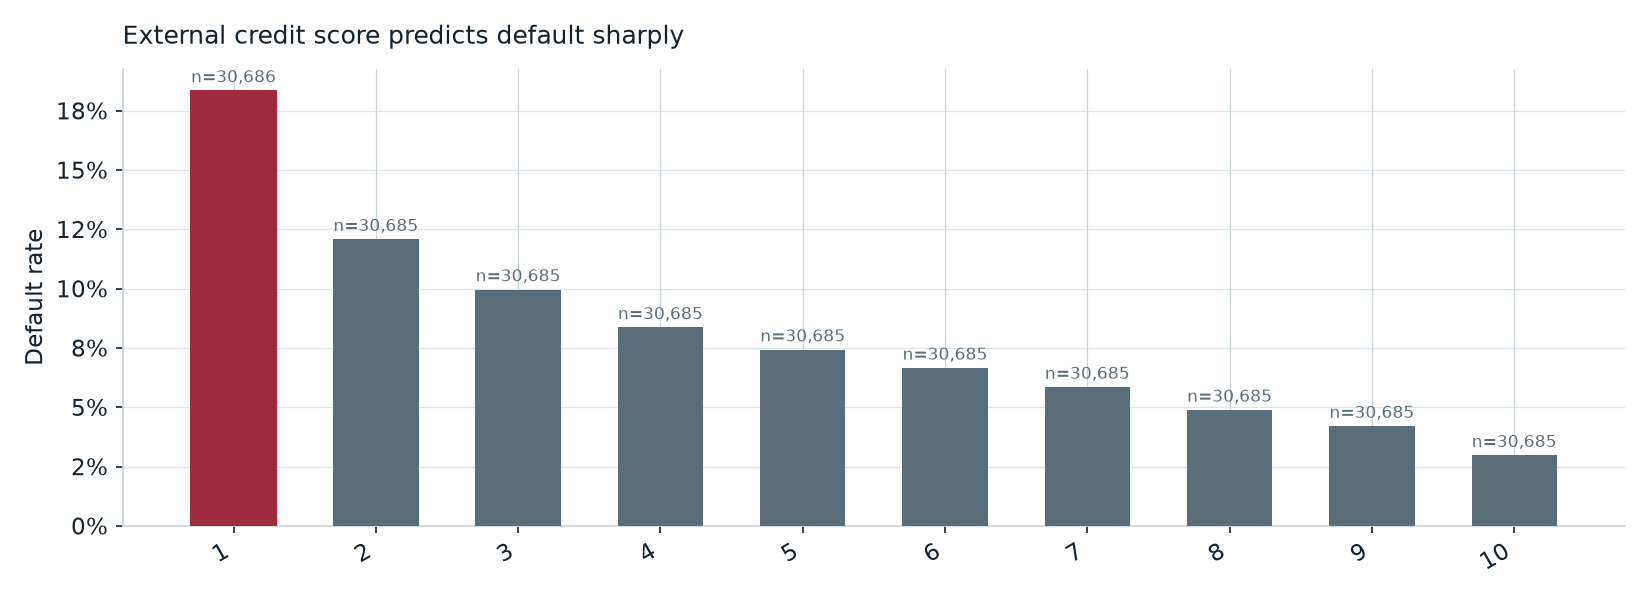

Younger applicants default more often


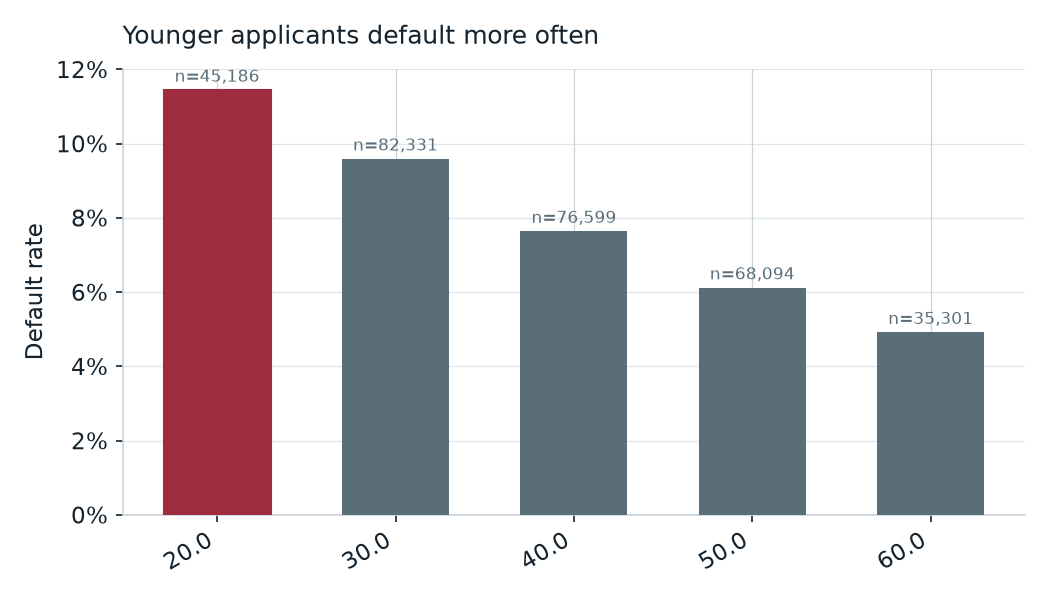

Short employment tenure is the riskiest segment


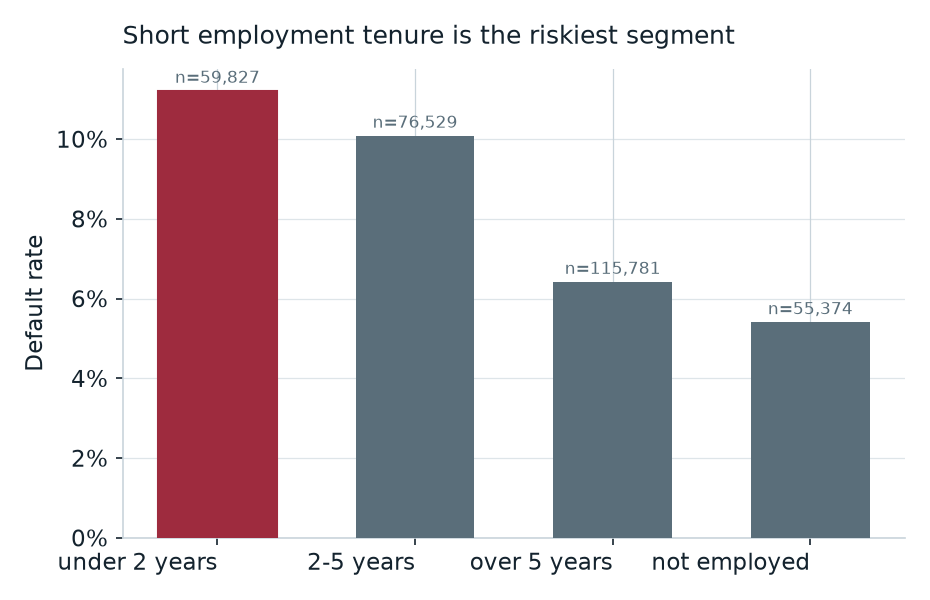

Loan burden relative to income has a non-linear relationship with default


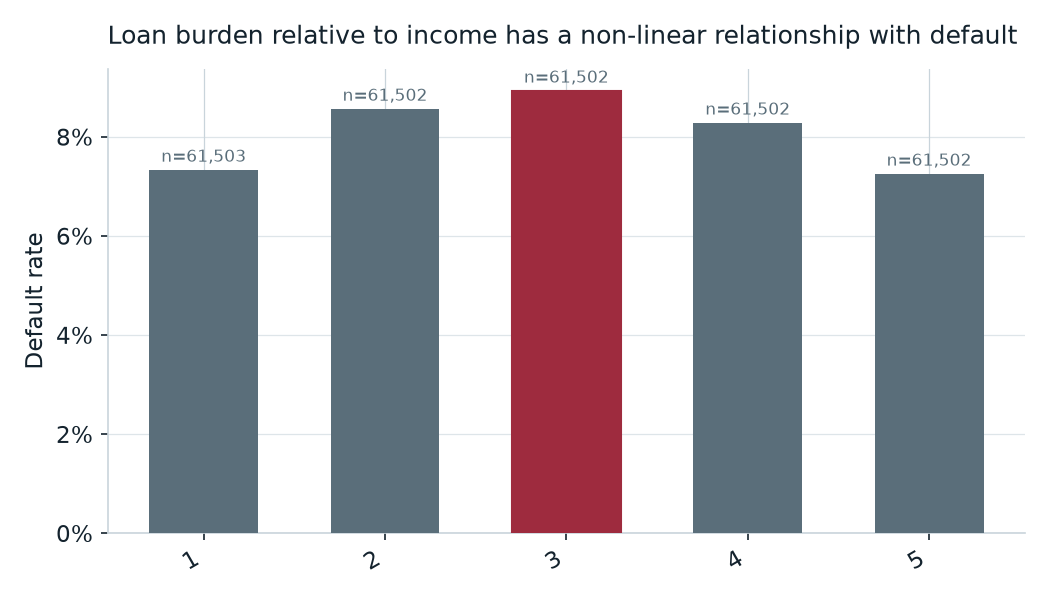

Loan type is associated with different risk levels


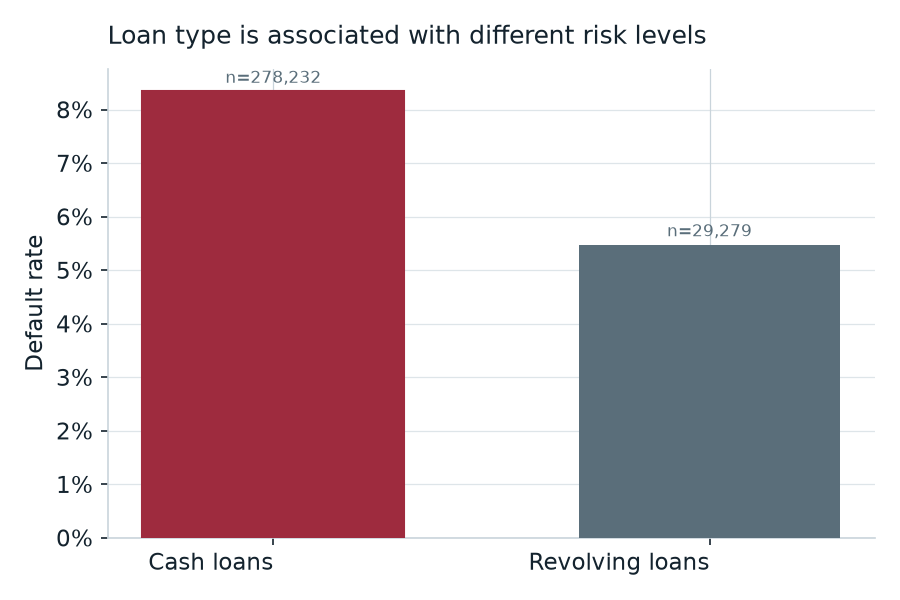

Overdue debt at other institutions is a strong warning sign


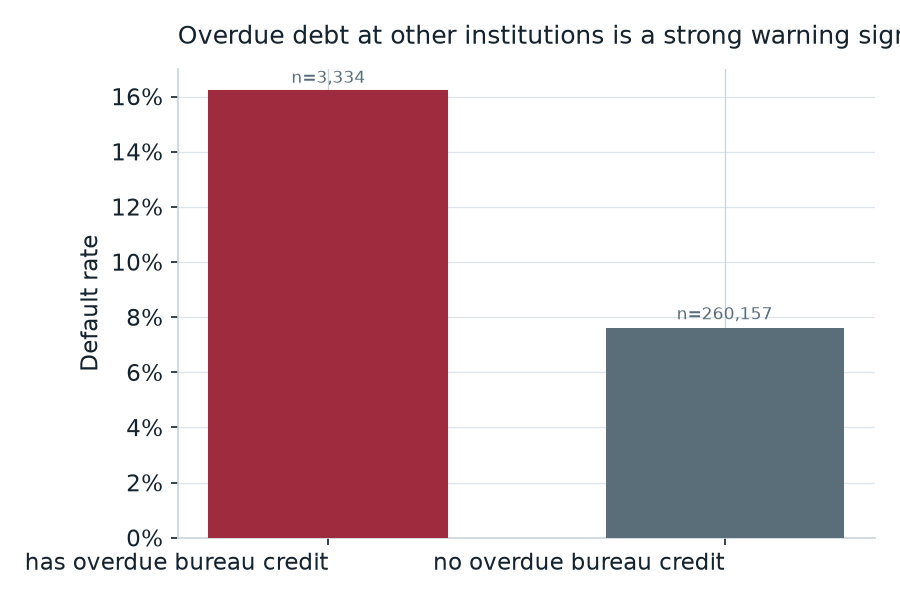

A past refusal at this lender predicts future default


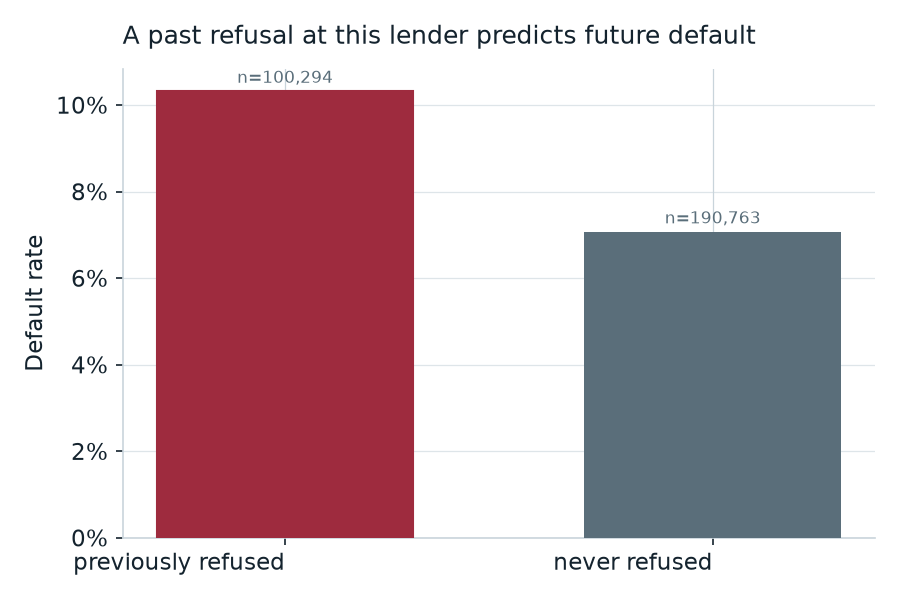

Late repayment behaviour on past installments carries forward


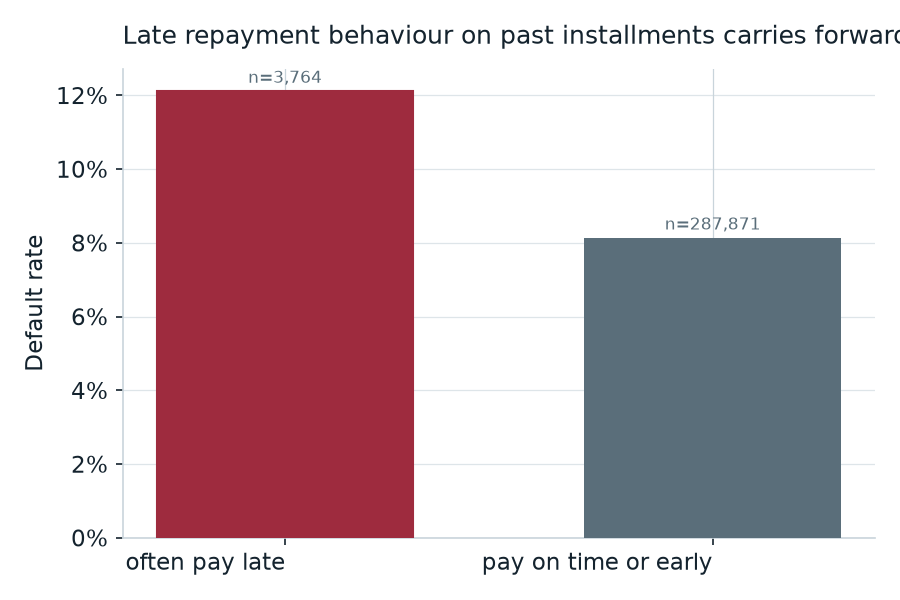

In [8]:
from IPython.display import Image, display as ipy_display

from src.eda import charts

chart_dir = Path(settings.charts_dir)
if not chart_dir.exists():
    charts.render_all(insights, missing, chart_dir)

for insight in insights:
    path = chart_dir / f"{insight.id}.png"
    if path.exists():
        print(insight.title)
        ipy_display(Image(filename=str(path)))

## 6. What this means for the model

The EDA drove four concrete decisions, all carried through into
`src/data/features.py` and `src/ml/train.py`:

1. **`DAYS_EMPLOYED = 365243`** (18.0% of rows) is a "not employed" sentinel,
   not a duration. Left alone it becomes a 1,000-year tenure that dominates
   every split, so it is mapped to `NULL` with the fact kept as
   `FLAG_NOT_EMPLOYED`.
2. **Missingness is informative**, not random — so it is left as `NaN` for
   LightGBM rather than imputed away.
3. **`EXT_SOURCE_*` dominate**, with a clean monotonic 6.2x risk gradient
   across deciles, so their mean/min/max/product are made explicit features
   rather than left for the trees to rediscover.
4. **8.07% positive rate (11.4:1)** is the central modelling constraint, and
   is why the imbalance study in `docs/MODEL_CARD.md` selects on PR-AUC
   rather than accuracy.

Full write-up: `docs/EDA_FINDINGS.md`. Model decisions: `docs/MODEL_CARD.md`.